In [21]:
# Members of group 10:
# Beatrice Zundra Rivera
# Clarence Trebita
# Emmanuel Noel C. Sanguyo
# Ryan Kenewene Aton

import pandas as pd

X_train = pd.read_csv("X_train.csv")
X_test = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test = pd.read_csv("y_test.csv").squeeze()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1669, 23)
X_test shape: (418, 23)
y_train shape: (1669,)
y_test shape: (418,)


In [3]:
print("Feature columns:")
print(X_train.columns.tolist())
print("\nFirst five training records:")
display(X_train.head())
print("\nTarget values:")
print(y_train.value_counts().sort_index())

Feature columns:
['Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'Gender_Male', 'CAEC_Frequently', 'CAEC_Sometimes', 'CAEC_no', 'CALC_Frequently', 'CALC_Sometimes', 'CALC_no', 'MTRANS_Bike', 'MTRANS_Motorbike', 'MTRANS_Public_Transportation', 'MTRANS_Walking']

First five training records:


,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,SMOKE,CH2O,SCC,...,CAEC_Frequently,CAEC_Sometimes,CAEC_no,CALC_Frequently,CALC_Sometimes,CALC_no,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking
0,0.248290,0.705537,1.045026,1,1,-0.375885,0.391801,0,0.253102,0,...,0,1,0,0,1,0,0,0,1,0
1,1.008501,-0.608067,0.505277,1,1,1.016483,-0.755149,0,-1.644954,0,...,0,1,0,0,0,1,0,0,1,0
2,3.702329,0.457500,-0.078269,1,1,0.207948,0.391801,0,-1.403908,0,...,0,1,0,0,0,1,0,0,0,0
3,-0.208354,0.416482,-1.265285,1,1,-0.345947,0.391801,0,-0.252848,0,...,1,0,0,0,0,1,0,0,1,0
4,-0.523216,-1.012212,-0.725998,1,1,-0.801583,0.596256,0,1.643643,0,...,0,0,1,0,1,0,0,0,1,0



Target values:
NObeyesdad
0    214
1    225
2    281
3    237
4    259
5    221
6    232
Name: count, dtype: int64


In [ ]:
X = X_train
y = y_train

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

print("\nNumber of features:", X.shape[1])
print("Number of target values:", y.shape[0])

Features (X): (1669, 23)
Target (y): (1669,)


In [6]:
from sklearn.tree import DecisionTreeClassifier

gini_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

gini_model.fit(X_train, y_train)

gini_pred = gini_model.predict(X_test)

print("Gini predictions completed.")
print("Number of predictions:", len(gini_pred))

Gini predictions completed.
Number of predictions: 418


In [7]:
entropy_model = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

entropy_pred = entropy_model.predict(X_test)

print("Entropy predictions completed.")
print("Number of predictions:", len(entropy_pred))

Entropy predictions completed.
Number of predictions: 418


In [10]:
from sklearn.metrics import accuracy_score

gini_accuracy = accuracy_score(y_test, gini_pred)
entropy_accuracy = accuracy_score(y_test, entropy_pred)

print("Gini Accuracy:", gini_accuracy)
print("Gini Accuracy: {:.2%}".format(gini_accuracy))

print("Entropy Accuracy:", entropy_accuracy)
print("Entropy Accuracy: {:.2%}".format(entropy_accuracy))

Gini Accuracy: 0.9401913875598086
Gini Accuracy: 94.02%
Entropy Accuracy: 0.9688995215311005
Entropy Accuracy: 96.89%


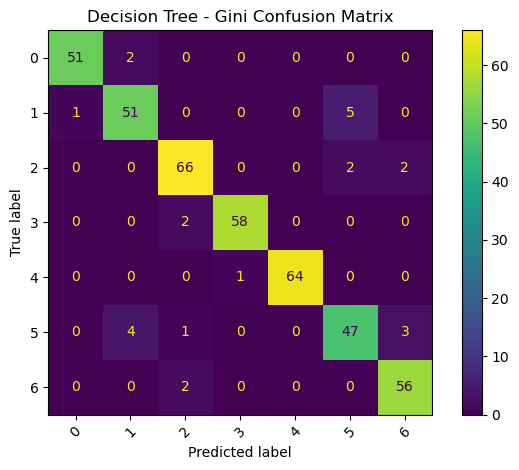

In [12]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    gini_pred,
    display_labels=sorted(y_test.unique()),
    xticks_rotation=45
)

plt.title("Decision Tree - Gini Confusion Matrix")
plt.tight_layout()
plt.show()

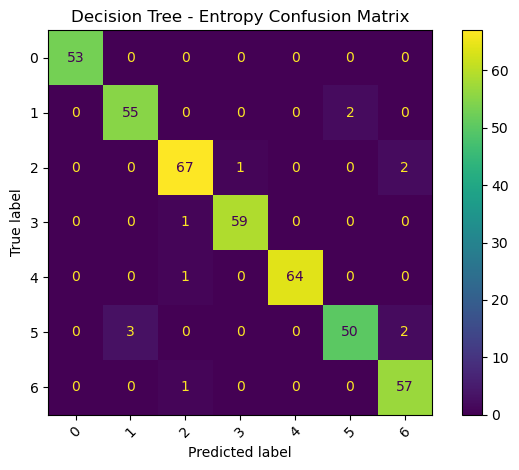

In [13]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    entropy_pred,
    display_labels=sorted(y_test.unique()),
    xticks_rotation=45
)

plt.title("Decision Tree - Entropy Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Gini Classification Report:")
print(classification_report(y_test, gini_pred))

print(___________________________________________)
print("Entropy Classification Report:")
print(classification_report(y_test, entropy_pred))

Gini Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97        53
           1       0.89      0.89      0.89        57
           2       0.93      0.94      0.94        70
           3       0.98      0.97      0.97        60
           4       1.00      0.98      0.99        65
           5       0.87      0.85      0.86        55
           6       0.92      0.97      0.94        58

    accuracy                           0.94       418
   macro avg       0.94      0.94      0.94       418
weighted avg       0.94      0.94      0.94       418

Entropy Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        53
           1       0.95      0.96      0.96        57
           2       0.96      0.96      0.96        70
           3       0.98      0.98      0.98        60
           4       1.00      0.98      0.99        65
           5       

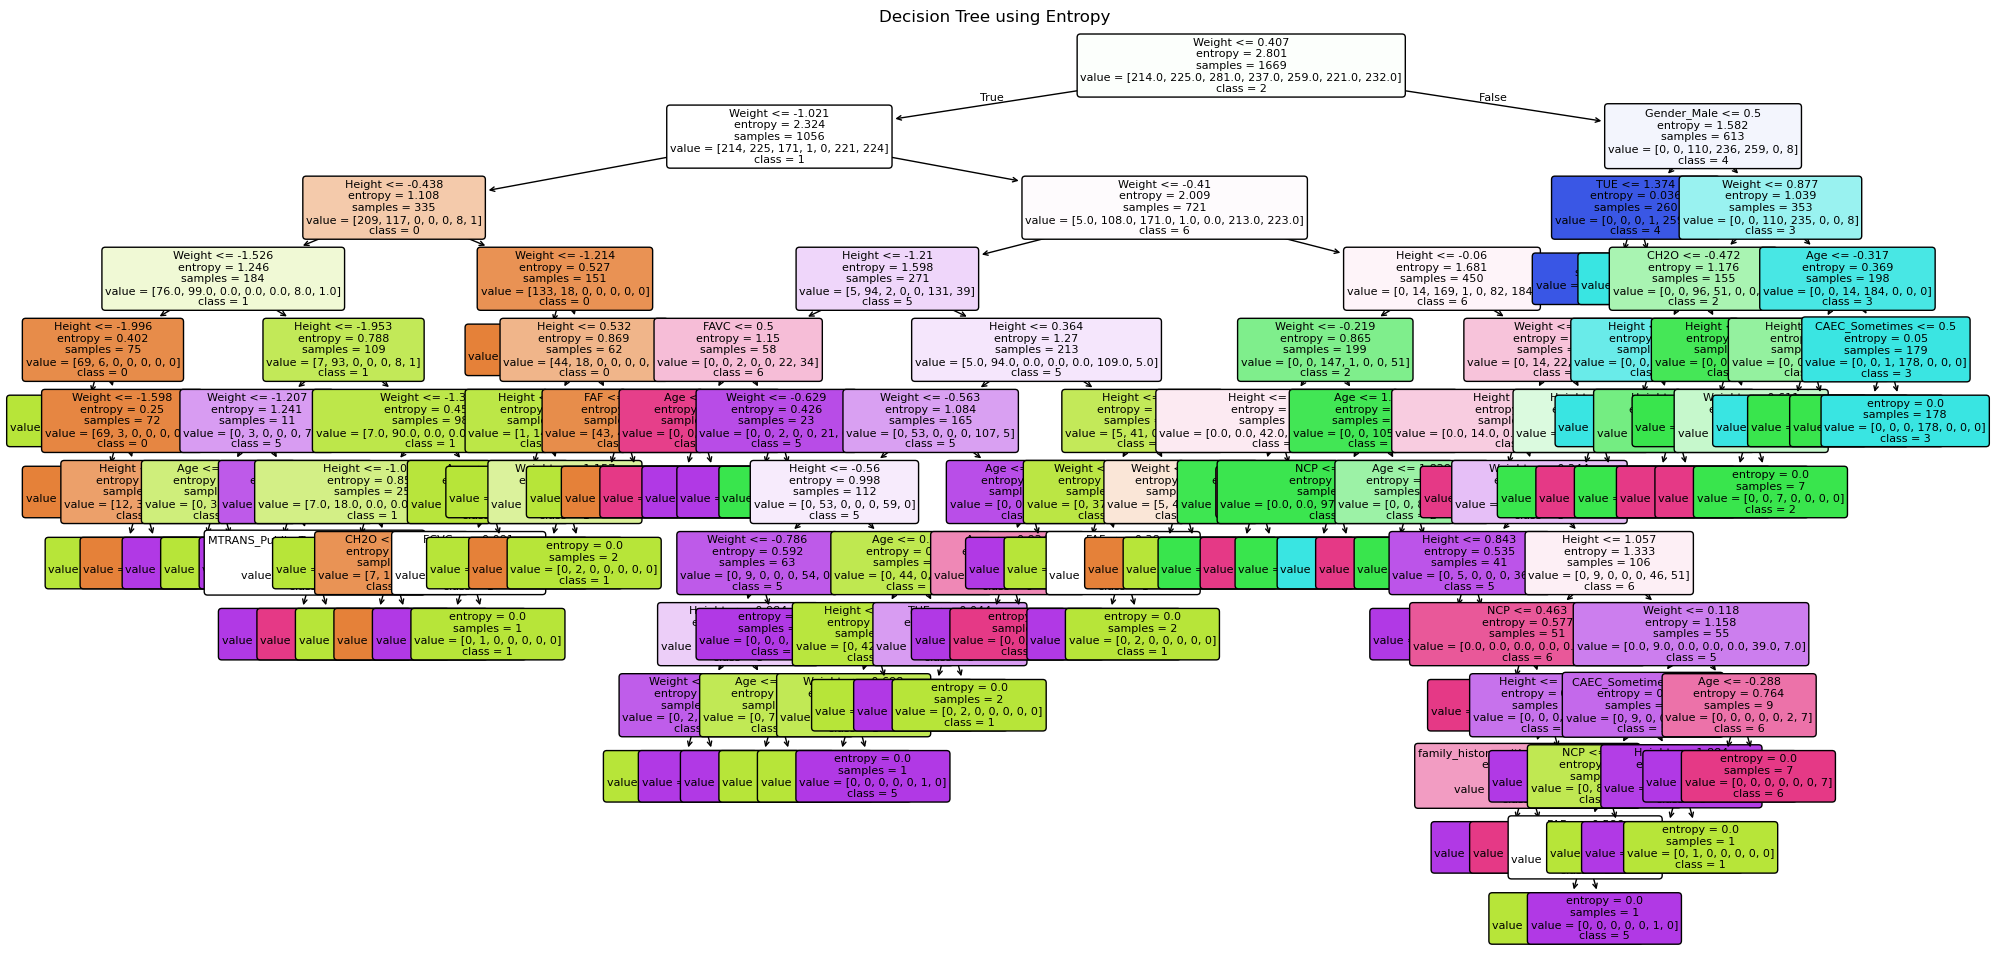

In [16]:
from sklearn.tree import plot_tree

plt.figure(figsize=(24, 12))

plot_tree(
    entropy_model,
    feature_names=X_train.columns,
    class_names=[str(c) for c in sorted(y_train.unique())],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree using Entropy")
plt.show()

Feature Importance:
Weight                            0.582852
Height                            0.203420
Gender_Male                       0.126929
Age                               0.030440
CH2O                              0.021821
FAVC                              0.010764
NCP                               0.007086
CAEC_Sometimes                    0.006537
FAF                               0.005504
TUE                               0.003202
family_history_with_overweight    0.000589
FCVC                              0.000428
MTRANS_Public_Transportation      0.000428
SCC                               0.000000
SMOKE                             0.000000
CAEC_Frequently                   0.000000
CAEC_no                           0.000000
CALC_Frequently                   0.000000
CALC_Sometimes                    0.000000
CALC_no                           0.000000
MTRANS_Bike                       0.000000
MTRANS_Motorbike                  0.000000
MTRANS_Walking                    

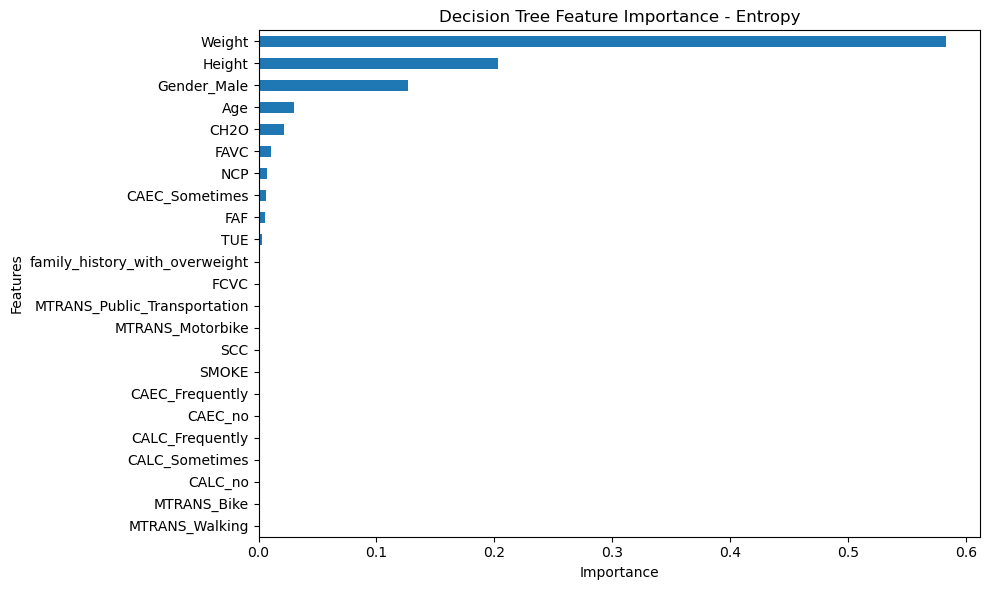

In [18]:
feature_importance = pd.Series(
    entropy_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("Feature Importance:")
print(feature_importance)

plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Decision Tree Feature Importance - Entropy")
plt.xlabel("Importance")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

In [19]:
from sklearn.tree import export_text

rules = export_text(
    entropy_model,
    feature_names=list(X_train.columns)
)

print(rules)

|--- Weight <= 0.41
|   |--- Weight <= -1.02
|   |   |--- Height <= -0.44
|   |   |   |--- Weight <= -1.53
|   |   |   |   |--- Height <= -2.00
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Height >  -2.00
|   |   |   |   |   |--- Weight <= -1.60
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- Weight >  -1.60
|   |   |   |   |   |   |--- Height <= -1.30
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |   |--- Height >  -1.30
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |--- Weight >  -1.53
|   |   |   |   |--- Height <= -1.95
|   |   |   |   |   |--- Weight <= -1.21
|   |   |   |   |   |   |--- Age <= -1.05
|   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |--- Age >  -1.05
|   |   |   |   |   |   |   |--- class: 1
|   |   |   |   |   |--- Weight >  -1.21
|   |   |   |   |   |   |--- Age <= -0.52
|   |   |   |   |   |   |   |--- class: 5
|   |   |   |   |   |   |--- Age >  -0.52
|   |   |   |   |   |   |   |--- MTRANS_Publi

In [ ]:
# Conclusion

# The Decision Tree classification model was successfully implemented using the approved and 
# cleansed obesity dataset. The dataset was divided into training and testing sets, and two 
# Decision Tree models were trained using different splitting criteria: Gini impurity and Entropy (Information Gain).
# The models were evaluated using accuracy, confusion matrices, and classification reports 
# containing precision, recall, and F1-score. The Decision Tree was also visualized to show 
# its learned splitting structure, while feature importance was examined to identify the features that contributed to the model's 
# predictions. A ruleset was generated to represent the decision paths learned by the model.
# The comparison of Gini and Entropy demonstrates how different splitting criteria can affect 
# Decision Tree classification performance. Overall, the experiment shows how Decision Trees 
# can be used to classify obesity levels while providing an interpretable model through its feature splits and decision rules.